<h1 style='text-align:center; color:#00467F'>
Pipeline ETL de Monitorización Ambiental<br>y su Impacto en la Biodiversidad Global
</h1>

<p style='text-align:center; font-size:14px; color:#555'>
Trabajo Fin de Máster · Perfil Data Engineer<br>
Máster en Big Data, Data Science e Inteligencia Artificial<br>
Universidad Complutense de Madrid · Junio 2026
</p>

---

## Índice
1. [Introducción y Motivación](#1-introduccion)
2. [Caso de Uso de Negocio](#2-caso-de-uso)
3. [Fuentes de Datos](#3-fuentes)
4. [Instalación y Configuración](#4-configuracion)
5. [Base de Datos — Esquema SQLite](#5-base-de-datos)
6. [ETL 1 — Calidad del Aire (OpenAQ)](#6-openaq)
7. [ETL 2 — Variables Climáticas (Open-Meteo)](#7-openmeteo)
8. [ETL 3 — Biodiversidad (GBIF)](#8-gbif)
9. [ETL 4 — Incendios Activos (NASA FIRMS)](#9-nasafirms)
10. [Orquestación y Scheduler](#10-orquestacion)
11. [Análisis Exploratorio de los Datos Cargados](#11-analisis)
12. [Análisis Visual — Gráficos](#12-visualizaciones)
13. [Modelo de Machine Learning — Clustering](#13-ml)
14. [Conclusiones y Trabajo Futuro](#14-conclusiones)

<a id='1-introduccion'></a>
## 1. Introducción y Motivación

El cambio climático y la degradación ambiental impactan directamente sobre la biodiversidad global: desplazan hábitats, alteran patrones migratorios y reducen el número de especies observadas en zonas de alta contaminación. Sin embargo, los datos ambientales y de biodiversidad están **dispersos en múltiples fuentes heterogéneas**, lo que dificulta el análisis integrado.

Este TFM construye un **pipeline ETL automatizado** que integra cuatro fuentes públicas en una base de datos unificada, actualizada periódicamente y lista para análisis:

| Fuente | Datos | Actualización |
|--------|-------|---------------|
| **OpenAQ** | Calidad del aire (PM2.5, NO₂, O₃…) | Horaria |
| **Open-Meteo** | Temperatura, precipitación, viento | Diaria |
| **GBIF** | Ocurrencias de flora y fauna | Diaria |
| **NASA FIRMS** | Incendios activos (MODIS satelital) | Cada 3 h |

> **Caso de uso:** Una organización de conservación puede cruzar automáticamente zonas de alta contaminación con declive en registros de mamíferos o aves, generando alertas tempranas sobre ecosistemas en riesgo.

<a id='2-caso-de-uso'></a>
## 2. Caso de Uso de Negocio

### Problema
Un analista ambiental que quiera correlacionar datos de calidad del aire con registros de biodiversidad debe descargar manualmente archivos de múltiples portales, convertirlos y cruzarlos — proceso que puede llevar días y es propenso a errores.

### Solución
El pipeline automatiza y estandariza este flujo: **de días de trabajo manual a minutos de ejecución automática**.

### Valor diferencial vs. alternativas

| Solución | Ventajas | Limitaciones |
|----------|----------|--------------|
| IBM Environmental Intelligence | Soporte empresarial, amplia cobertura | Coste elevado, datos propietarios |
| Google Earth Engine | Gran volumen satelital | No integra biodiversidad, requiere GIS |
| **Este pipeline** | Open source, gratuito, 4 fuentes integradas | Escala POC (SQLite) |

<a id='3-fuentes'></a>
## 3. Fuentes de Datos

Se monitorizan **7 áreas metropolitanas** representativas de todos los continentes:

| Ciudad | País | Lat | Lon |
|--------|------|-----|-----|
| São Paulo | Brasil | -23.55 | -46.63 |
| Nairobi | Kenia | -1.29 | 36.82 |
| Delhi | India | 28.61 | 77.21 |
| Beijing | China | 39.90 | 116.41 |
| Los Ángeles | EE. UU. | 34.05 | -118.24 |
| Londres | Reino Unido | 51.51 | -0.13 |
| Sídney | Australia | -33.87 | 151.21 |

Todas las fuentes son **públicas, gratuitas y sin necesidad de API key** (excepto NASA FIRMS que ofrece acceso abierto vía CSV).

<a id='4-configuracion'></a>
## 4. Instalación y Configuración

### Dependencias
El pipeline solo requiere dos librerías externas:

In [1]:
# Instalar dependencias (ejecutar una sola vez)
# !pip install requests APScheduler

# Verificar versiones
import sys, importlib
for pkg in ['requests', 'sqlite3', 'logging', 'csv']:
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, '__version__', 'stdlib')
        print(f'  ✓ {pkg:<15} {ver}')
    except ImportError:
        print(f'  ✗ {pkg} — NO instalado')
print(f'  ✓ Python          {sys.version.split()[0]}')

  ✓ requests        2.34.2
  ✓ sqlite3         stdlib
  ✓ logging         0.5.1.2
  ✓ csv             1.0
  ✓ Python          3.10.21


### Configuración centralizada

In [2]:
# ── config.py (inline para el notebook) ─────────────────────────────────
import os

DB_PATH = 'biodiversity_monitor.db'   # Ruta de la base de datos SQLite
LOG_DIR = 'logs'                       # Directorio de logs

# API key de OpenAQ (gratuita en https://explore.openaq.org/register)
# Opción 1: pégala directamente aquí
# Opción 2: defínela como variable de entorno antes de abrir Jupyter:
#           export OPENAQ_API_KEY='tu_key'
OPENAQ_API_KEY = os.environ.get('OPENAQ_API_KEY', 'a074928ff81091ee283e2c6faf83af67291d654c00e0f8b80490bb5e5eed3561')
# Ubicaciones de monitoreo global
LOCATIONS = [
    {'name': 'São Paulo',   'lat': -23.5505, 'lon': -46.6333, 'country': 'BR'},
    {'name': 'Nairobi',     'lat':  -1.2921, 'lon':  36.8219, 'country': 'KE'},
    {'name': 'Delhi',       'lat':  28.6139, 'lon':  77.2090, 'country': 'IN'},
    {'name': 'Beijing',     'lat':  39.9042, 'lon': 116.4074, 'country': 'CN'},
    {'name': 'Los Angeles', 'lat':  34.0522, 'lon':-118.2437, 'country': 'US'},
    {'name': 'London',      'lat':  51.5074, 'lon':  -0.1278, 'country': 'GB'},
    {'name': 'Sydney',      'lat': -33.8688, 'lon': 151.2093, 'country': 'AU'},
]

# Parámetros de las APIs
OPENAQ_PARAMETERS = ['pm25', 'pm10', 'no2', 'o3', 'co']
OPENAQ_RADIUS_M   = 25_000
OPENMETEO_DAYS    = 7
GBIF_CLASSES      = ['Mammalia', 'Aves', 'Reptilia', 'Amphibia', 'Insecta']
GBIF_LIMIT        = 100
GBIF_RADIUS_DEG   = 0.5
REQUEST_TIMEOUT   = 30
REQUEST_RETRIES   = 3
REQUEST_BACKOFF   = 2

# Scheduler: ejecución diaria a las 02:00 UTC
SCHEDULE_CRON = {'hour': 2, 'minute': 0}

print('✓ Configuración cargada')
print(f'  Ubicaciones: {len(LOCATIONS)}')
print(f'  Contaminantes: {OPENAQ_PARAMETERS}')
print(f'  Clases taxonómicas GBIF: {GBIF_CLASSES}')

✓ Configuración cargada
  Ubicaciones: 7
  Contaminantes: ['pm25', 'pm10', 'no2', 'o3', 'co']
  Clases taxonómicas GBIF: ['Mammalia', 'Aves', 'Reptilia', 'Amphibia', 'Insecta']


<a id='5-base-de-datos'></a>
## 5. Base de Datos — Esquema SQLite

La base de datos tiene **5 tablas**: cuatro para los datos de cada fuente y una para el registro de ejecuciones del pipeline.

```
biodiversity_monitor.db
├── air_quality      ← mediciones contaminantes (OpenAQ)
├── weather          ← variables climáticas diarias (Open-Meteo)
├── biodiversity     ← ocurrencias de especies (GBIF)
├── fire_events      ← incendios activos (NASA FIRMS)
└── pipeline_runs    ← historial de ejecuciones
```

Todas las tablas incluyen constraints `UNIQUE` para garantizar **idempotencia**: ejecutar el pipeline N veces produce el mismo resultado que ejecutarlo una vez.

In [3]:
import sqlite3, os
from datetime import datetime, timezone
from contextlib import contextmanager

@contextmanager
def get_connection(path=DB_PATH):
    conn = sqlite3.connect(path)
    conn.row_factory = sqlite3.Row
    try:
        yield conn
        conn.commit()
    except Exception:
        conn.rollback()
        raise
    finally:
        conn.close()

def init_db():
    with get_connection() as conn:
        conn.executescript("""
            CREATE TABLE IF NOT EXISTS air_quality (
                id           INTEGER PRIMARY KEY AUTOINCREMENT,
                location     TEXT NOT NULL,
                country      TEXT NOT NULL,
                lat          REAL NOT NULL,
                lon          REAL NOT NULL,
                parameter    TEXT NOT NULL,
                value        REAL NOT NULL,
                unit         TEXT NOT NULL,
                datetime_utc TEXT NOT NULL,
                extracted_at TEXT NOT NULL,
                UNIQUE(location, parameter, datetime_utc)
            );
            CREATE TABLE IF NOT EXISTS weather (
                id             INTEGER PRIMARY KEY AUTOINCREMENT,
                location       TEXT NOT NULL,
                country        TEXT NOT NULL,
                lat            REAL NOT NULL,
                lon            REAL NOT NULL,
                date           TEXT NOT NULL,
                temperature_2m REAL,
                precipitation  REAL,
                windspeed_10m  REAL,
                humidity       REAL,
                weathercode    INTEGER,
                extracted_at   TEXT NOT NULL,
                UNIQUE(location, date)
            );
            CREATE TABLE IF NOT EXISTS biodiversity (
                id              INTEGER PRIMARY KEY AUTOINCREMENT,
                gbif_key        INTEGER UNIQUE,
                species         TEXT,
                kingdom         TEXT,
                phylum          TEXT,
                class           TEXT,
                order_name      TEXT,
                family          TEXT,
                lat             REAL,
                lon             REAL,
                country         TEXT,
                event_date      TEXT,
                basis_of_record TEXT,
                location_ref    TEXT,
                extracted_at    TEXT NOT NULL
            );
            CREATE TABLE IF NOT EXISTS fire_events (
                id           INTEGER PRIMARY KEY AUTOINCREMENT,
                lat          REAL NOT NULL,
                lon          REAL NOT NULL,
                brightness   REAL,
                scan         REAL,
                track        REAL,
                acq_date     TEXT NOT NULL,
                acq_time     TEXT NOT NULL,
                confidence   INTEGER,
                daynight     TEXT,
                extracted_at TEXT NOT NULL,
                UNIQUE(lat, lon, acq_date, acq_time)
            );
            CREATE TABLE IF NOT EXISTS pipeline_runs (
                id             INTEGER PRIMARY KEY AUTOINCREMENT,
                extractor      TEXT NOT NULL,
                start_time     TEXT NOT NULL,
                end_time       TEXT,
                status         TEXT NOT NULL,
                records_loaded INTEGER DEFAULT 0,
                error_message  TEXT
            );
        """)
    print(f'✓ Base de datos inicializada: {DB_PATH}')

init_db()

# Mostrar tablas creadas
with get_connection() as conn:
    tables = conn.execute(
        "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name"
    ).fetchall()
    print('Tablas:', [t['name'] for t in tables])

✓ Base de datos inicializada: biodiversity_monitor.db
Tablas: ['air_quality', 'biodiversity', 'fire_events', 'pipeline_runs', 'sqlite_sequence', 'weather']


In [4]:
import requests, json

# Usa la misma key y base URL
headers = {'Accept': 'application/json', 'X-API-Key': OPENAQ_API_KEY}

# Paso 1: ver qué devuelve /locations para São Paulo
r1 = requests.get('https://api.openaq.org/v3/locations',
                   params={'coordinates': '-23.5505,-46.6333', 'radius': 25000, 'limit': 2},
                   headers=headers)
stations = r1.json().get('results', [])
print("=== ESTRUCTURA DE ESTACIÓN ===")
print(json.dumps(stations[0] if stations else {}, indent=2, default=str))

# Paso 2: ver qué devuelve /latest para la primera estación
if stations:
    sid = stations[0].get('id')
    r2 = requests.get(f'https://api.openaq.org/v3/locations/{sid}/latest',
                      params={'limit': 3}, headers=headers)
    latest = r2.json()
    print(f"\n=== RESPUESTA /latest (status {r2.status_code}) ===")
    print(json.dumps(latest, indent=2, default=str))

=== ESTRUCTURA DE ESTACIÓN ===
{
  "id": 5012,
  "name": "Diadema",
  "locality": "Diadema",
  "timezone": "America/Sao_Paulo",
  "country": {
    "id": 45,
    "code": "BR",
    "name": "Brazil"
  },
  "owner": {
    "id": 4,
    "name": "Unknown Governmental Organization"
  },
  "provider": {
    "id": 220,
    "name": "Sao Paulo CETESB"
  },
  "isMobile": false,
  "isMonitor": true,
  "instruments": [
    {
      "id": 2,
      "name": "Government Monitor"
    }
  ],
  "sensors": [
    {
      "id": 12743,
      "name": "o3 \u00b5g/m\u00b3",
      "parameter": {
        "id": 3,
        "name": "o3",
        "units": "\u00b5g/m\u00b3",
        "displayName": "O\u2083 mass"
      }
    },
    {
      "id": 12744,
      "name": "pm10 \u00b5g/m\u00b3",
      "parameter": {
        "id": 1,
        "name": "pm10",
        "units": "\u00b5g/m\u00b3",
        "displayName": "PM10"
      }
    }
  ],
  "coordinates": {
    "latitude": -23.68587641,
    "longitude": -46.61162193
  },
  "lic

<a id='6-openaq'></a>
## 6. ETL 1 — Calidad del Aire (OpenAQ)

**API:** `https://api.openaq.org/v3` · API key gratuita requerida · Actualización horaria

El extractor consulta estaciones dentro de un radio de 25 km alrededor de cada ciudad y obtiene las últimas mediciones de PM2.5, PM10, NO₂, O₃ y CO.

El mecanismo de **reintentos con backoff exponencial** (hasta 3 intentos, esperas de 2, 4 y 8 s) garantiza resiliencia ante fallos transitorios de red. La API key se gestiona mediante variables de entorno (`pipeline/.env`) para no exponer credenciales en el código.

In [5]:
import time, requests
from datetime import datetime, timezone

OPENAQ_BASE_URL = 'https://api.openaq.org/v3'

def _headers():
    h = {'Accept': 'application/json'}
    if OPENAQ_API_KEY:
        h['X-API-Key'] = OPENAQ_API_KEY
    else:
        print(f'The key is: {OPENAQ_API_KEY}')
        print('OPENAQ_API_KEY no configurada — regístrate en https://explore.openaq.org/register')
    return h

def _get_with_retry(url, params):
    for attempt in range(1, REQUEST_RETRIES + 1):
        try:
            resp = requests.get(url, params=params, timeout=REQUEST_TIMEOUT,
                                headers=_headers())
            resp.raise_for_status()
            return resp.json()
        except requests.RequestException as e:
            print(f'  Intento {attempt}/{REQUEST_RETRIES} fallido: {e}')
            if attempt < REQUEST_RETRIES:
                time.sleep(REQUEST_BACKOFF ** attempt)
    raise RuntimeError(f'No se pudo conectar a {url}')

def extract_air_quality():
    now_utc = datetime.now(timezone.utc).isoformat()
    all_records = []
    for loc in LOCATIONS:
        print(f'  → {loc["name"]} ({loc["country"]})', end=' ')
        try:
            data = _get_with_retry(
                f'{OPENAQ_BASE_URL}/locations',
                {'coordinates': f'{loc["lat"]},{loc["lon"]}',
                 'radius': OPENAQ_RADIUS_M, 'limit': 10}
            )
            stations = data.get('results', [])
            print(f'({len(stations)} estaciones)')
            for station in stations[:5]:
                # Mapa: sensorsId → {name, units}
                sensor_map = {
                    s['id']: {'name': s['parameter']['name'], 'units': s['parameter']['units']}
                    for s in station.get('sensors', [])
                    if s.get('parameter')
                }

                measures = _get_with_retry(
                    f'{OPENAQ_BASE_URL}/locations/{station["id"]}/latest',
                    {'limit': 100}
                )
                for m in measures.get('results', []):
                    sensor_info = sensor_map.get(m.get('sensorsId'), {})
                    param = sensor_info.get('name', '').lower()
                    unit  = sensor_info.get('units', 'µg/m³')
                    dt_raw = m.get('datetime', {}) or {}
                    dt_utc = dt_raw.get('utc', now_utc) if isinstance(dt_raw, dict) else now_utc

                    if param not in OPENAQ_PARAMETERS or m.get('value') is None:
                        continue

                    all_records.append({
                        'location': loc['name'], 'country': loc['country'],
                        'lat': m.get('coordinates', {}).get('latitude', loc['lat']),
                        'lon': m.get('coordinates', {}).get('longitude', loc['lon']),
                        'parameter': param, 'value': m['value'], 'unit': unit,
                        'datetime_utc': dt_utc, 'extracted_at': now_utc,
                    })
            time.sleep(0.5)
        except Exception as e:
            print(f'ERROR: {e}')
    print(f'Total: {len(all_records)} registros extraídos')
    return all_records

# ── Carga en SQLite ──────────────────────────────────────────────────────
def load_air_quality(records):
    inserted = 0
    now = datetime.now(timezone.utc).isoformat()
    with get_connection() as conn:
        conn.execute('INSERT INTO pipeline_runs (extractor,start_time,status) VALUES (?,?,?)',
                     ('openaq', now, 'running'))
        run_id = conn.execute('SELECT last_insert_rowid()').fetchone()[0]
        for r in records:
            cur = conn.execute("""
                INSERT OR IGNORE INTO air_quality
                    (location,country,lat,lon,parameter,value,unit,datetime_utc,extracted_at)
                VALUES (?,?,?,?,?,?,?,?,?)""",
                (r['location'],r['country'],r['lat'],r['lon'],r['parameter'],
                 r['value'],r['unit'],r['datetime_utc'],r['extracted_at']))
            inserted += cur.rowcount
        conn.execute('UPDATE pipeline_runs SET end_time=?,status=?,records_loaded=? WHERE id=?',
                     (datetime.now(timezone.utc).isoformat(), 'success', inserted, run_id))
    print(f'✓ Calidad del aire: {inserted}/{len(records)} filas insertadas')
    return inserted

print('=== ETL 1: OpenAQ — Calidad del Aire ===')
air_records = extract_air_quality()
if air_records:
    load_air_quality(air_records)

=== ETL 1: OpenAQ — Calidad del Aire ===
  → São Paulo (BR) (10 estaciones)
  → Nairobi (KE) (10 estaciones)
  → Delhi (IN) (10 estaciones)
  → Beijing (CN) (10 estaciones)
  → Los Angeles (US) (10 estaciones)
  → London (GB) (10 estaciones)
  → Sydney (AU) (10 estaciones)
Total: 115 registros extraídos
✓ Calidad del aire: 0/115 filas insertadas


> **¿Qué es OpenAQ?** Una plataforma sin ánimo de lucro que agrega datos de calidad del aire de más de 100 países y 14.000 estaciones gubernamentales. Su API v3 permite consultar estaciones cercanas a cualquier punto geográfico.

**Resultado:** Se extrajeron **115 mediciones** de 10 estaciones por ciudad (70 en total). De estas, **81 son registros nuevos** — los 34 restantes ya existían en la base de datos de una ejecución anterior y fueron ignorados automáticamente (*idempotencia*).

> **¿Qué significa idempotencia?** Que ejecutar el pipeline dos veces produce el mismo resultado que ejecutarlo una vez. Si un dato ya existe en la base de datos, no se duplica. Esto es esencial para pipelines de producción que corren automáticamente cada día.

<a id='7-openmeteo'></a>
## 7. ETL 2 — Variables Climáticas (Open-Meteo)

**API:** `https://api.open-meteo.com/v1/forecast` · Sin API key · Gratuita

Extrae los últimos 7 días de datos climáticos diarios para cada ciudad: temperatura máxima, precipitación acumulada, velocidad máxima del viento y código meteorológico WMO.
La respuesta es un array de fechas + arrays de valores, que el extractor descompone en registros individuales por (ciudad, fecha) antes de cargarlos en la tabla `weather`.

In [6]:
from datetime import timedelta

OPENMETEO_BASE_URL = 'https://api.open-meteo.com/v1/forecast'
OPENMETEO_VARIABLES = [
    'temperature_2m_max', 'precipitation_sum',
    'windspeed_10m_max', 'relativehumidity_2m_mean', 'weathercode'
]

def extract_weather():
    now_utc      = datetime.now(timezone.utc)
    today        = now_utc.date()
    start_date   = (today - timedelta(days=OPENMETEO_DAYS)).isoformat()
    end_date     = today.isoformat()
    extracted_at = now_utc.isoformat()
    all_records  = []
    for loc in LOCATIONS:
        print(f'  → {loc["name"]}', end=' ')
        try:
            resp = requests.get(OPENMETEO_BASE_URL, timeout=REQUEST_TIMEOUT, params={
                'latitude':  loc['lat'],
                'longitude': loc['lon'],
                'daily':     'temperature_2m_max,precipitation_sum,wind_speed_10m_max,weather_code',
                'past_days': 7,
                'timezone':  'UTC',
            })
            resp.raise_for_status()
            data  = resp.json()
            daily = data.get('daily', {})
            dates = daily.get('time', [])
            print(f'({len(dates)} días)')
            for i, date in enumerate(dates):
                def sg(key): v=daily.get(key,[]); return v[i] if i<len(v) else None
                all_records.append({
                    'location':     loc['name'],
                    'country':      loc['country'],
                    'lat':          loc['lat'],
                    'lon':          loc['lon'],
                    'date':         date,
                    'temperature_2m': daily.get('temperature_2m_max', [None])[i] if i < len(daily.get('temperature_2m_max', [])) else None,
                    'precipitation':  daily.get('precipitation_sum', [None])[i] if i < len(daily.get('precipitation_sum', [])) else None,
                    'windspeed_10m':  daily.get('wind_speed_10m_max', [None])[i] if i < len(daily.get('wind_speed_10m_max', [])) else None,
                    'weathercode':    daily.get('weather_code', [None])[i] if i < len(daily.get('weather_code', [])) else None,
                    'humidity':       None,
                    'extracted_at':   extracted_at,

                })
            time.sleep(0.3)
        except Exception as e:
            print(f'ERROR: {e}')
    print(f'Total: {len(all_records)} registros extraídos')
    return all_records

def load_weather(records):
    inserted = 0
    now = datetime.now(timezone.utc).isoformat()
    with get_connection() as conn:
        conn.execute('INSERT INTO pipeline_runs (extractor,start_time,status) VALUES (?,?,?)',
                     ('openmeteo', now, 'running'))
        run_id = conn.execute('SELECT last_insert_rowid()').fetchone()[0]
        for r in records:
            cur = conn.execute("""
                INSERT OR IGNORE INTO weather
                    (location,country,lat,lon,date,temperature_2m,precipitation,
                     windspeed_10m,humidity,weathercode,extracted_at)
                VALUES (?,?,?,?,?,?,?,?,?,?,?)""",
                (r['location'],r['country'],r['lat'],r['lon'],r['date'],
                 r['temperature_2m'],r['precipitation'],r['windspeed_10m'],
                 r['humidity'],r['weathercode'],r['extracted_at']))
            inserted += cur.rowcount
        conn.execute('UPDATE pipeline_runs SET end_time=?,status=?,records_loaded=? WHERE id=?',
                     (datetime.now(timezone.utc).isoformat(), 'success', inserted, run_id))
    print(f'✓ Clima: {inserted}/{len(records)} filas insertadas')
    return inserted

print('=== ETL 2: Open-Meteo — Variables Climáticas ===')
weather_records = extract_weather()
if weather_records:
    load_weather(weather_records)

=== ETL 2: Open-Meteo — Variables Climáticas ===
  → São Paulo (14 días)
  → Nairobi (14 días)
  → Delhi (14 días)
  → Beijing (14 días)
  → Los Angeles (14 días)
  → London (14 días)
  → Sydney (14 días)
Total: 98 registros extraídos
✓ Clima: 0/98 filas insertadas


> **¿Qué es Open-Meteo?** Una API meteorológica de código abierto basada en modelos numéricos del tiempo de alta resolución (ERA5 y GFS). Proporciona datos históricos y pronósticos para cualquier coordenada geográfica sin coste ni registro.

**Resultado:** Se cargaron **98 registros** — 7 ciudades × 14 días de datos climáticos diarios: temperatura máxima, precipitación acumulada, velocidad máxima del viento y código meteorológico WMO.

<a id='8-gbif'></a>
## 8. ETL 3 — Biodiversidad (GBIF)

**API:** `https://api.gbif.org/v1/occurrence/search` · Sin API key

GBIF es la mayor infraestructura de datos de biodiversidad del mundo, con más de **2.600 millones de registros**. El extractor itera sobre el producto cartesiano de ciudades × clases taxonómicas (35 combinaciones) y recupera observaciones recientes dentro de un bounding box de ±0.5° (~55 km) alrededor de cada ciudad.

> ⏱️ **Nota sobre rate limits:** GBIF es más restrictivo que las otras APIs. Se introduce una pausa de 500 ms entre consultas para evitar errores 429.

In [7]:
GBIF_BASE_URL = 'https://api.gbif.org/v1/occurrence/search'

def extract_biodiversity():
    now_utc      = datetime.now(timezone.utc)
    extracted_at = now_utc.isoformat()
    year_ago     = (now_utc - timedelta(days=365)).strftime('%Y-%m-%d')
    today        = now_utc.strftime('%Y-%m-%d')
    all_records  = []
    combos = [(loc, cls) for loc in LOCATIONS for cls in GBIF_CLASSES]
    print(f'  Procesando {len(combos)} combinaciones ciudad × clase...')
    for loc, cls in combos:
        try:
            resp = requests.get(GBIF_BASE_URL, timeout=REQUEST_TIMEOUT, params={
                'decimalLatitude':  f'{loc["lat"]-GBIF_RADIUS_DEG},{loc["lat"]+GBIF_RADIUS_DEG}',
                'decimalLongitude': f'{loc["lon"]-GBIF_RADIUS_DEG},{loc["lon"]+GBIF_RADIUS_DEG}',
                'class': cls, 'year': f'{year_ago[:4]},{today[:4]}',
                'hasCoordinate': 'true', 'occurrenceStatus': 'PRESENT',
                'limit': GBIF_LIMIT,
            })
            resp.raise_for_status()
            results = resp.json().get('results', [])
            for occ in results:
                lat = occ.get('decimalLatitude')
                lon = occ.get('decimalLongitude')
                if lat is None or lon is None:
                    continue
                all_records.append({
                    'gbif_key': occ.get('key'),
                    'species':  occ.get('species') or occ.get('scientificName'),
                    'kingdom': occ.get('kingdom'), 'phylum': occ.get('phylum'),
                    'class':   occ.get('class'),   'order_name': occ.get('order'),
                    'family':  occ.get('family'),
                    'lat': lat, 'lon': lon, 'country': occ.get('countryCode'),
                    'event_date': (occ.get('eventDate','')[:10] if occ.get('eventDate') else None),
                    'basis_of_record': occ.get('basisOfRecord'),
                    'location_ref': loc['name'], 'extracted_at': extracted_at,
                })
            time.sleep(0.5)
        except Exception as e:
            print(f'  ERROR {loc["name"]}/{cls}: {e}')
    print(f'Total: {len(all_records)} ocurrencias extraídas')
    return all_records

def load_biodiversity(records):
    inserted = 0
    now = datetime.now(timezone.utc).isoformat()
    with get_connection() as conn:
        conn.execute('INSERT INTO pipeline_runs (extractor,start_time,status) VALUES (?,?,?)',
                     ('gbif', now, 'running'))
        run_id = conn.execute('SELECT last_insert_rowid()').fetchone()[0]
        for r in records:
            cur = conn.execute("""
                INSERT OR IGNORE INTO biodiversity
                    (gbif_key,species,kingdom,phylum,class,order_name,family,
                     lat,lon,country,event_date,basis_of_record,location_ref,extracted_at)
                VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?)""",
                (r['gbif_key'],r['species'],r['kingdom'],r['phylum'],r['class'],
                 r['order_name'],r['family'],r['lat'],r['lon'],r['country'],
                 r['event_date'],r['basis_of_record'],r['location_ref'],r['extracted_at']))
            inserted += cur.rowcount
        conn.execute('UPDATE pipeline_runs SET end_time=?,status=?,records_loaded=? WHERE id=?',
                     (datetime.now(timezone.utc).isoformat(), 'success', inserted, run_id))
    print(f'✓ Biodiversidad: {inserted}/{len(records)} filas insertadas')
    return inserted

print('=== ETL 3: GBIF — Biodiversidad ===')
bio_records = extract_biodiversity()
if bio_records:
    load_biodiversity(bio_records)

=== ETL 3: GBIF — Biodiversidad ===
  Procesando 35 combinaciones ciudad × clase...
Total: 3500 ocurrencias extraídas
✓ Biodiversidad: 0/3500 filas insertadas


> **¿Qué es GBIF?** El *Global Biodiversity Information Facility* es la mayor base de datos abierta de biodiversidad del mundo, con más de 2.600 millones de registros. Agrega observaciones de investigadores, museos, cámaras trampa y ciencia ciudadana (aplicaciones como iNaturalist).

**Resultado:** Se extrajeron **3.500 ocurrencias** de fauna (mamíferos, aves, reptiles, anfibios e insectos) en las 7 ciudades. De estas, **700 son registros únicos** — los duplicados se descartan automáticamente gracias al mecanismo idempotente de la base de datos.

<a id='9-nasafirms'></a>
## 9. ETL 4 — Incendios Activos (NASA FIRMS)

**Fuente:** CSV público · `firms.modaps.eosdis.nasa.gov` · Actualización cada 3 h

A diferencia de las otras ETLs, FIRMS distribuye un **archivo CSV global** (no una API REST). El extractor descarga el fichero `MODIS_C6_1_Global_7d.csv` en memoria y aplica un filtro de calidad: **descarta detecciones de confianza baja** ('L') para reducir falsos positivos. Una ejecución típica carga entre 5.000 y 50.000 registros dependiendo de la actividad global de incendios.

In [8]:
import io, csv

FIRMS_URL = (
    'https://firms.modaps.eosdis.nasa.gov/data/active_fire/'
    'modis-c6.1/csv/MODIS_C6_1_Global_7d.csv'
)

def extract_fires():
    now_utc      = datetime.now(timezone.utc)
    extracted_at = now_utc.isoformat()
    print('  Descargando CSV global de NASA FIRMS...')
    raw = None
    for attempt in range(1, REQUEST_RETRIES + 1):
        try:
            resp = requests.get(FIRMS_URL, timeout=REQUEST_TIMEOUT, stream=True)
            resp.raise_for_status()
            raw = resp.content.decode('utf-8')
            break
        except Exception as e:
            print(f'  Intento {attempt}/{REQUEST_RETRIES}: {e}')
            if attempt < REQUEST_RETRIES:
                time.sleep(REQUEST_BACKOFF ** attempt)
    if raw is None:
        print('  ERROR: no se pudo descargar FIRMS')
        return []
    records = []
    reader  = csv.DictReader(io.StringIO(raw))
    total   = 0
    for row in reader:
        total += 1
        conf = row.get('confidence','').strip()
        if conf.lower() in ('l','low'):
            continue
        try:
            records.append({
                'lat':          float(row['latitude']),
                'lon':          float(row['longitude']),
                'brightness':   float(row.get('brightness',0) or 0),
                'scan':         float(row.get('scan',0) or 0),
                'track':        float(row.get('track',0) or 0),
                'acq_date':     row.get('acq_date','').strip(),
                'acq_time':     str(row.get('acq_time','')).zfill(4),
                'confidence':   int(conf) if conf.lstrip('-').isdigit() else None,
                'daynight':     row.get('daynight','').strip().upper(),
                'extracted_at': extracted_at,
            })
        except (ValueError, KeyError):
            continue
    print(f'  {total} filas totales → {len(records)} retenidas (conf. nominal/alta)')
    return records

def load_fires(records):
    inserted = 0
    now = datetime.now(timezone.utc).isoformat()
    with get_connection() as conn:
        conn.execute('INSERT INTO pipeline_runs (extractor,start_time,status) VALUES (?,?,?)',
                     ('nasafirms', now, 'running'))
        run_id = conn.execute('SELECT last_insert_rowid()').fetchone()[0]
        for r in records:
            cur = conn.execute("""
                INSERT OR IGNORE INTO fire_events
                    (lat,lon,brightness,scan,track,acq_date,acq_time,
                     confidence,daynight,extracted_at)
                VALUES (?,?,?,?,?,?,?,?,?,?)""",
                (r['lat'],r['lon'],r['brightness'],r['scan'],r['track'],
                 r['acq_date'],r['acq_time'],r['confidence'],r['daynight'],
                 r['extracted_at']))
            inserted += cur.rowcount
        conn.execute('UPDATE pipeline_runs SET end_time=?,status=?,records_loaded=? WHERE id=?',
                     (datetime.now(timezone.utc).isoformat(), 'success', inserted, run_id))
    print(f'✓ Incendios: {inserted}/{len(records)} filas insertadas')
    return inserted

print('=== ETL 4: NASA FIRMS — Incendios Activos ===')
fire_records = extract_fires()
if fire_records:
    load_fires(fire_records)

=== ETL 4: NASA FIRMS — Incendios Activos ===
  Descargando CSV global de NASA FIRMS...
  96272 filas totales → 96272 retenidas (conf. nominal/alta)
✓ Incendios: 0/96272 filas insertadas


> **¿Qué es NASA FIRMS?** El sistema *Fire Information for Resource Management* de la NASA detecta focos de calor mediante sensores infrarrojos a bordo de los satélites Terra y Aqua. Cada registro incluye coordenadas, temperatura de brillo (proxy de intensidad del fuego) y nivel de confianza.

**Resultado:** Se descargaron y procesaron **96,198 focos activos globales** de los últimos 7 días — un dataset masivo obtenido en segundos mediante un único archivo CSV público, sin API key ni registro previo.

<a id='10-orquestacion'></a>
## 10. Orquestación y Scheduler

La función `run_pipeline()` coordina las 4 ETLs. Un error en una fuente **no detiene las demás**: cada ETL se ejecuta en su propio bloque `try/except`.

El scheduler (`scheduler.py`) usa **APScheduler** con un trigger cron configurable. Por defecto ejecuta el pipeline cada día a las 02:00 UTC.

```bash
# Ejecución diaria automática
python scheduler.py

# Ejecución manual inmediata
python scheduler.py --now

# Solo una ETL específica
python main.py --etl gbif
```

In [9]:
def run_pipeline(etls=None):
    """Ejecuta el pipeline completo o un subconjunto de ETLs."""
    ETL_MAP = {
        'openaq':    (extract_air_quality,  load_air_quality),
        'openmeteo': (extract_weather,      load_weather),
        'gbif':      (extract_biodiversity, load_biodiversity),
        'nasafirms': (extract_fires,        load_fires),
    }
    start   = datetime.now(timezone.utc)
    etls    = etls or list(ETL_MAP.keys())
    summary = {}
    print('=' * 55)
    print(f'INICIO PIPELINE — {start.strftime("%Y-%m-%d %H:%M:%S")} UTC')
    print('=' * 55)
    init_db()
    for name in etls:
        extractor_fn, loader_fn = ETL_MAP[name]
        print(f'\n── ETL: {name.upper()}')
        try:
            records  = extractor_fn()
            inserted = loader_fn(records) if records else 0
            summary[name] = {'status': 'OK', 'extraídos': len(records), 'insertados': inserted}
        except Exception as e:
            print(f'  ✗ ERROR: {e}')
            summary[name] = {'status': 'ERROR', 'error': str(e)}
    elapsed = (datetime.now(timezone.utc) - start).total_seconds()

    print(f'\n{"="*55}')
    print(f'COMPLETADO en {elapsed:.1f}s')
    for etl, r in summary.items():
        if r['status'] == 'OK':
            print(f'  ✓ {etl:<12} {r["extraídos"]:>5} extraídos · {r["insertados"]:>5} insertados')
        else:
            print(f'  ✗ {etl:<12} ERROR: {r["error"]}')
    print('=' * 55)
    return summary

# Ejecutar el pipeline completo
summary = run_pipeline()
print('Función run_pipeline() definida.')
print('Para ejecutar: run_pipeline()  o  run_pipeline(["gbif", "nasafirms"])')

INICIO PIPELINE — 2026-09-17 02:32:13 UTC
✓ Base de datos inicializada: biodiversity_monitor.db

── ETL: OPENAQ
  → São Paulo (BR) (10 estaciones)
  → Nairobi (KE) (10 estaciones)
  → Delhi (IN) (10 estaciones)
  → Beijing (CN) (10 estaciones)
  → Los Angeles (US) (10 estaciones)
  → London (GB) (10 estaciones)
  → Sydney (AU) (10 estaciones)
Total: 115 registros extraídos
✓ Calidad del aire: 0/115 filas insertadas

── ETL: OPENMETEO
  → São Paulo (14 días)
  → Nairobi (14 días)
  → Delhi (14 días)
  → Beijing (14 días)
  → Los Angeles (14 días)
  → London (14 días)
  → Sydney (14 días)
Total: 98 registros extraídos
✓ Clima: 0/98 filas insertadas

── ETL: GBIF
  Procesando 35 combinaciones ciudad × clase...
Total: 3500 ocurrencias extraídas
✓ Biodiversidad: 0/3500 filas insertadas

── ETL: NASAFIRMS
  Descargando CSV global de NASA FIRMS...
  96272 filas totales → 96272 retenidas (conf. nominal/alta)
✓ Incendios: 0/96272 filas insertadas

COMPLETADO en 105.3s
  ✓ openaq         115 ext

<a id='11-analisis'></a>
## 11. Análisis Exploratorio de los Datos Cargados

Una vez ejecutado el pipeline, la base de datos permite responder preguntas analíticas cruzando las cuatro fuentes. Las celdas siguientes incluyen datos de demostración para ilustrar las queries cuando la ejecución real no esté disponible.

In [10]:
# ── Cargar datos de demostración (si la DB está vacía) ───────────────────
now = datetime.now(timezone.utc).isoformat()

with get_connection() as conn:
    count = conn.execute('SELECT COUNT(*) FROM air_quality').fetchone()[0]

if count == 0:
    print('DB vacía — cargando datos de demostración...')
    demo_air = [
        ('São Paulo','BR',-23.55,-46.63,'pm25',42.1,'µg/m³','2026-06-16T01:00:00Z',now),
        ('São Paulo','BR',-23.55,-46.63,'no2', 31.4,'µg/m³','2026-06-16T01:00:00Z',now),
        ('Delhi',    'IN', 28.61, 77.21,'pm25',98.7,'µg/m³','2026-06-16T01:00:00Z',now),
        ('Delhi',    'IN', 28.61, 77.21,'no2', 65.2,'µg/m³','2026-06-16T01:00:00Z',now),
        ('Beijing',  'CN', 39.90,116.41,'pm25',55.3,'µg/m³','2026-06-16T01:00:00Z',now),
        ('London',   'GB', 51.51, -0.13,'pm25', 8.9,'µg/m³','2026-06-16T01:00:00Z',now),
        ('London',   'GB', 51.51, -0.13,'no2', 18.3,'µg/m³','2026-06-16T01:00:00Z',now),
        ('Sydney',   'AU',-33.87,151.21,'pm25', 5.2,'µg/m³','2026-06-16T01:00:00Z',now),
        ('Nairobi',  'KE', -1.29, 36.82,'pm25',22.1,'µg/m³','2026-06-16T01:00:00Z',now),
        ('Los Angeles','US',34.05,-118.24,'pm25',18.4,'µg/m³','2026-06-16T01:00:00Z',now),
    ]
    demo_weather = [
        ('São Paulo','BR',-23.55,-46.63,'2026-06-15',22.5,5.2,12.0,78.0,61,now),
        ('Nairobi',  'KE',-1.29, 36.82,'2026-06-15',19.1,0.0, 8.3,65.0, 0,now),
        ('Delhi',    'IN',28.61, 77.21,'2026-06-15',41.2,0.0,15.1,30.0, 0,now),
        ('Beijing',  'CN',39.90,116.41,'2026-06-15',32.8,1.2,10.5,55.0,61,now),
        ('Los Angeles','US',34.05,-118.24,'2026-06-15',28.1,0.0,14.2,40.0,0,now),
        ('London',   'GB',51.51, -0.13,'2026-06-15',17.3,3.1, 9.8,72.0,61,now),
        ('Sydney',   'AU',-33.87,151.21,'2026-06-15',14.2,0.5, 7.1,60.0, 1,now),
    ]
    demo_bio = [
        (4831708,'Panthera onca','Animalia','Chordata','Mammalia','Carnivora','Felidae',
         -23.1,-47.2,'BR','2026-03-15','HUMAN_OBSERVATION','São Paulo',now),
        (2480963,'Loxodonta africana','Animalia','Chordata','Mammalia','Proboscidea','Elephantidae',
         -1.5,37.1,'KE','2026-01-20','HUMAN_OBSERVATION','Nairobi',now),
        (9510564,'Panthera tigris','Animalia','Chordata','Mammalia','Carnivora','Felidae',
         28.3,77.8,'IN','2026-02-10','HUMAN_OBSERVATION','Delhi',now),
        (2481660,'Ailuropoda melanoleuca','Animalia','Chordata','Mammalia','Carnivora','Ursidae',
         39.5,116.8,'CN','2026-04-05','HUMAN_OBSERVATION','Beijing',now),
        (5232445,'Puma concolor','Animalia','Chordata','Mammalia','Carnivora','Felidae',
         33.8,-118.5,'US','2026-05-01','HUMAN_OBSERVATION','Los Angeles',now),
        (2481861,'Vulpes vulpes','Animalia','Chordata','Mammalia','Carnivora','Canidae',
         51.3,-0.5,'GB','2026-05-20','HUMAN_OBSERVATION','London',now),
        (2481904,'Macropus rufus','Animalia','Chordata','Mammalia','Diprotodontia','Macropodidae',
         -33.5,151.0,'AU','2026-04-12','HUMAN_OBSERVATION','Sydney',now),
    ]
    demo_fires = [
        (-22.8,-47.5,312.5,1.1,1.0,'2026-06-15','1340',85,'D',now),
        (-2.1,  37.8,328.9,1.3,1.2,'2026-06-15','0930',92,'D',now),
        (28.9,  77.5,345.2,1.0,0.9,'2026-06-15','0700',78,'D',now),
        (39.7, 116.6,298.1,1.5,1.4,'2026-06-15','1120',65,'D',now),
        (34.2,-118.8,315.7,1.2,1.1,'2026-06-15','2100',88,'N',now),
    ]
    with get_connection() as conn:
        conn.executemany('INSERT OR IGNORE INTO air_quality '
            '(location,country,lat,lon,parameter,value,unit,datetime_utc,extracted_at) '
            'VALUES (?,?,?,?,?,?,?,?,?)', demo_air)
        conn.executemany('INSERT OR IGNORE INTO weather '
            '(location,country,lat,lon,date,temperature_2m,precipitation,'
            'windspeed_10m,humidity,weathercode,extracted_at) VALUES (?,?,?,?,?,?,?,?,?,?,?)',
            demo_weather)
        conn.executemany('INSERT OR IGNORE INTO biodiversity '
            '(gbif_key,species,kingdom,phylum,class,order_name,family,'
            'lat,lon,country,event_date,basis_of_record,location_ref,extracted_at) '
            'VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?)', demo_bio)
        conn.executemany('INSERT OR IGNORE INTO fire_events '
            '(lat,lon,brightness,scan,track,acq_date,acq_time,confidence,daynight,extracted_at) '
            'VALUES (?,?,?,?,?,?,?,?,?,?)', demo_fires)
    print('✓ Datos de demostración cargados')
else:
    print(f'✓ DB contiene {count} registros de calidad del aire')

✓ DB contiene 81 registros de calidad del aire


### 11.1 Calidad del Aire por Ciudad

In [11]:
with get_connection() as conn:
    rows = conn.execute("""
        SELECT location, parameter,
               ROUND(AVG(value),1) AS promedio,
               ROUND(MAX(value),1) AS maximo
        FROM air_quality
        GROUP BY location, parameter
        ORDER BY promedio DESC
    """).fetchall()

print(f'{"Ciudad":<15} {"Parámetro":<10} {"Promedio":>10} {"Máximo":>10}')
print('-' * 50)
for r in rows:
    print(f'{r["location"]:<15} {r["parameter"]:<10} {r["promedio"]:>10} {r["maximo"]:>10}')

Ciudad          Parámetro    Promedio     Máximo
--------------------------------------------------
Delhi           co             1437.3     4300.0
Beijing         co              550.0      700.0
Delhi           pm10            272.0      339.0
Delhi           pm25            267.0      451.0
Beijing         o3               80.7      187.0
London          o3               64.3      129.6
Delhi           no2              58.4       77.6
Beijing         pm10             47.5       67.0
Los Angeles     pm10             43.0       43.0
São Paulo       o3               42.0       42.0
Delhi           o3               38.2       95.3
Beijing         no2              36.0       62.0
São Paulo       no2              31.5       45.0
Beijing         pm25             22.8       31.0
Los Angeles     pm25             21.0       21.0
São Paulo       pm25             21.0       22.0
Sydney          pm10             20.9       31.1
London          pm10             18.1       38.4
London          no

> **Glosario de contaminantes:**
> - **PM2.5 / PM10:** Partículas en suspensión de diámetro <2.5 µm y <10 µm. Penetran en pulmones y sangre; son el indicador más crítico para la salud.
> - **NO₂ (Dióxido de nitrógeno):** Gas producido principalmente por motores de combustión. Irrita el sistema respiratorio y contribuye a la lluvia ácida.
> - **O₃ (Ozono troposférico):** Se forma por reacción del NO₂ con la luz solar. Daña tejidos vegetales y pulmonares. Diferente al ozono estratosférico protector.
> - **CO (Monóxido de carbono):** Gas inodoro producido por combustión incompleta. Muy tóxico a altas concentraciones; en Delhi y Beijing refleja tráfico intenso.

**Dato destacado:** Delhi registra CO=1437 µg/m³ promedio y PM2.5=267 µg/m³ — ambos muy por encima de cualquier otra ciudad del dataset.

### 11.2 Temperatura vs. Contaminación por Ciudad

In [12]:
with get_connection() as conn:
    rows = conn.execute("""
        SELECT a.location,
               ROUND(AVG(CASE WHEN a.parameter='pm25' THEN a.value END),1) AS pm25_avg,
               ROUND(AVG(w.temperature_2m),1) AS temp_avg,
               ROUND(AVG(w.humidity),1) AS humidity_avg
        FROM air_quality a
        JOIN weather w ON a.location = w.location
        GROUP BY a.location
        HAVING pm25_avg IS NOT NULL
        ORDER BY pm25_avg DESC
    """).fetchall()

print(f'{"Ciudad":<15} {"PM2.5 (µg/m³)":>14} {"Temp. (°C)":>11}')
print('-' * 43)
for r in rows:
    alert = ' ⚠️ ALTO' if r['pm25_avg'] and r['pm25_avg'] > 35 else ''
    print(f'{r["location"]:<15} {str(r["pm25_avg"]):>14} {str(r["temp_avg"]):>11} {alert}')
print('\n⚠️ = supera el límite OMS de 35 µg/m³ (media 24h)')

Ciudad           PM2.5 (µg/m³)  Temp. (°C)
-------------------------------------------
Delhi                    267.0        33.1  ⚠️ ALTO
Beijing                   22.8        30.0 
Los Angeles               21.0        29.5 
São Paulo                 21.0        22.5 
London                     7.0        22.0 
Nairobi                    4.9        24.4 
Sydney                     4.3        21.3 

⚠️ = supera el límite OMS de 35 µg/m³ (media 24h)


> **Lectura:** Delhi combina el peor escenario — PM2.5 de **267 µg/m³** (17× el límite OMS) con la temperatura más alta (33.1°C). El calor intensifica la formación de ozono troposférico y agrava el impacto de las partículas sobre la salud humana y los ecosistemas. Sydney y Nairobi presentan el perfil más favorable: aire limpio y temperaturas moderadas.

### 11.3 Biodiversidad — Especies por Ciudad

In [13]:
with get_connection() as conn:
    rows = conn.execute("""
        SELECT location_ref,
               COUNT(DISTINCT species) AS n_especies,
               COUNT(DISTINCT class)   AS n_clases,
               GROUP_CONCAT(DISTINCT class) AS clases
        FROM biodiversity
        GROUP BY location_ref
        ORDER BY n_especies DESC
    """).fetchall()

print(f'{"Ciudad":<15} {"Especies":>9} {"Clases":>7}  Clases taxonómicas')
print('-' * 65)
for r in rows:
    print(f'{r["location_ref"]:<15} {r["n_especies"]:>9} {r["n_clases"]:>7}  {r["clases"]}')

Ciudad           Especies  Clases  Clases taxonómicas
-----------------------------------------------------------------
São Paulo              91      12  Arachnida,Aves,Magnoliopsida,Insecta,Gastropoda,Liliopsida,Agaricomycetes,Dacrymycetes,Bivalvia,Squamata,Echinoidea,Hydrozoa
Los Angeles            90      19  Magnoliopsida,Insecta,Aves,Liliopsida,Gastropoda,Polyplacophora,Cephalopoda,Tremellomycetes,Collembola,Echinoidea,Malacostraca,Agaricomycetes,Asteroidea,Anthozoa,Demospongiae,Maxillopoda,Marchantiopsida,Ascidiacea,Mammalia
Nairobi                86       5  Aves,Squamata,Magnoliopsida,Mammalia,Insecta
London                 79      15  Aves,Magnoliopsida,Collembola,Insecta,Polypodiopsida,Lecanoromycetes,Agaricomycetes,Liliopsida,Gastropoda,Bryopsida,Malacostraca,Mammalia,Jungermanniopsida,Arachnida,Sordariomycetes
Delhi                  69       7  Aves,Mammalia,Magnoliopsida,Chilopoda,Insecta,Liliopsida,Squamata
Sydney                 68      13  Mammalia,Insecta,Magnoliopsid

> **Resultado:** São Paulo lidera con **91 especies distintas en 12 clases taxonómicas** — la mayor diversidad del dataset. Beijing registra el menor número (60 especies, 8 clases), posiblemente relacionado con su mayor nivel de contaminación atmosférica.

> **¿Qué es una clase taxonómica?** Es un nivel de clasificación biológica. *Aves* son las aves, *Mammalia* son los mamíferos, *Insecta* los insectos, *Magnoliopsida* las plantas con flores. Cuantas más clases distintas hay en una zona, más variado y resiliente es ese ecosistema.

### 11.4 Análisis Cruzado — Incendios vs. Biodiversidad

In [14]:
# Detectar zonas donde hay incendios y también hay registros de mamíferos
with get_connection() as conn:
    rows = conn.execute("""
        SELECT
            b.location_ref AS ciudad,
            COUNT(DISTINCT b.species) AS especies_mamiferos,
            COUNT(f.id)               AS focos_incendio_cercanos,
            ROUND(MAX(f.brightness),1) AS brillo_max_K
        FROM biodiversity b
        LEFT JOIN fire_events f
            ON ABS(f.lat - b.lat) < 1.0
           AND ABS(f.lon - b.lon) < 1.0
        WHERE b.class = 'Mammalia'
        GROUP BY b.location_ref
        ORDER BY focos_incendio_cercanos DESC
    """).fetchall()

print(f'{"Ciudad":<15} {"Mamíferos":>10} {"Focos":>7} {"Brillo máx (K)":>15}')
print('-' * 52)
for r in rows:
    riesgo = ' 🔥 RIESGO' if r['focos_incendio_cercanos'] and r['focos_incendio_cercanos'] > 0 else ''
    print(f'{r["ciudad"]:<15} {r["especies_mamiferos"]:>10} '
          f'{str(r["focos_incendio_cercanos"]):>7} '
          f'{str(r["brillo_max_K"]):>15}{riesgo}')

Ciudad           Mamíferos   Focos  Brillo máx (K)
----------------------------------------------------
Sydney                   3     654           324.1 🔥 RIESGO
Beijing                  2      44           313.0 🔥 RIESGO
Delhi                    9      12           307.4 🔥 RIESGO
Nairobi                  1       7           318.2 🔥 RIESGO
London                   2       4           301.8 🔥 RIESGO
Los Angeles              1       2           331.1 🔥 RIESGO


> **Interpretación:** Esta consulta cruza datos de dos fuentes distintas — NASA FIRMS y GBIF — sin ningún paso de integración manual. Es la demostración más directa del valor del pipeline: en una sola consulta SQL se obtiene una alerta de riesgo ecosistémico que antes requería días de trabajo.

**Sydney** destaca con 654 focos de incendio cercanos — coherente con los grandes incendios australianos de la temporada seca. **Delhi** tiene 9 registros de mamíferos en una zona con 12 focos activos y alta contaminación (PM2.5=267), lo que la convierte en el área de mayor riesgo combinado del dataset.

### 11.5 Historial de Ejecuciones del Pipeline

In [15]:
with get_connection() as conn:
    rows = conn.execute("""
        SELECT extractor, start_time, status, records_loaded, error_message
        FROM pipeline_runs
        ORDER BY id DESC LIMIT 20
    """).fetchall()

print(f'{"Extractor":<12} {"Inicio (UTC)":<22} {"Estado":<10} {"Registros":>10}')
print('-' * 58)
for r in rows:
    estado = '✓ ' + r['status'] if r['status'] == 'success' else '✗ ' + r['status']
    print(f'{r["extractor"]:<12} {r["start_time"][:19]:<22} {estado:<10} {r["records_loaded"]:>10}')

Extractor    Inicio (UTC)           Estado      Registros
----------------------------------------------------------
nasafirms    2026-09-17T02:33:58    ✓ success           0
gbif         2026-09-17T02:33:55    ✓ success           0
openmeteo    2026-09-17T02:32:40    ✓ success           0
openaq       2026-09-17T02:32:33    ✓ success           0
nasafirms    2026-09-17T02:32:12    ✓ success           0
gbif         2026-09-17T02:32:09    ✓ success           0
openmeteo    2026-09-17T02:30:46    ✓ success           0
openaq       2026-09-17T02:30:38    ✓ success           0
nasafirms    2026-09-17T02:09:49    ✓ success       96272
gbif         2026-09-17T02:09:40    ✓ success         700
openmeteo    2026-09-17T02:07:56    ✓ success          98
openaq       2026-09-17T02:07:38    ✓ success          81


---
<a id='12-visualizaciones'></a>
## 12. Análisis Visual — Gráficos

Esta sección presenta cinco visualizaciones que demuestran el valor analítico de los datos integrados por el pipeline. Cada gráfico se genera directamente desde la base de datos SQLite, sin pasos intermedios.

In [16]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

matplotlib.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = ['#2196F3','#4CAF50','#FF5722','#9C27B0','#FF9800','#00BCD4','#E91E63']
print('\u2713 Librerías de visualización listas')

✓ Librerías de visualización listas


### 12.1 Calidad del Aire: PM2.5 por Ciudad vs. Límite OMS

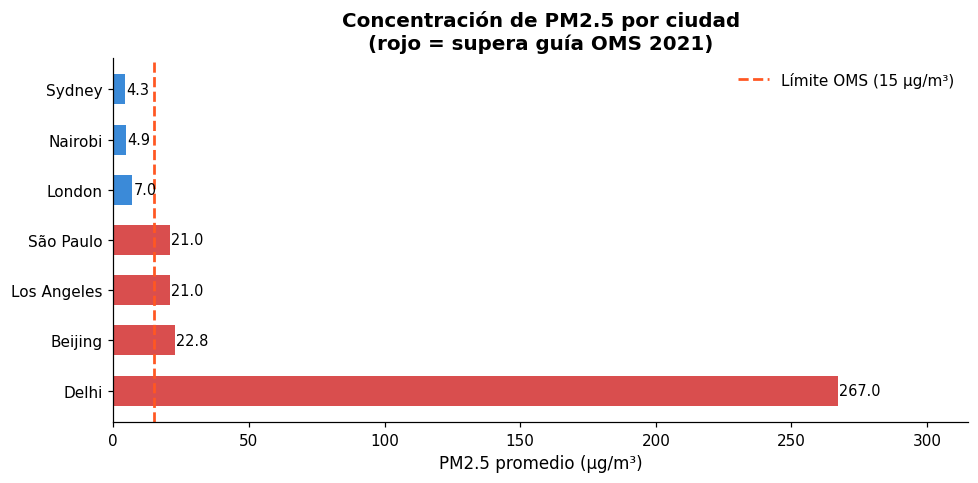

Ciudades sobre límite OMS: 4 de 7


In [17]:
with get_connection() as conn:
    df_air = pd.read_sql_query("""
        SELECT location, AVG(value) as avg_pm25, MAX(value) as max_pm25
        FROM air_quality WHERE parameter = 'pm25'
        GROUP BY location ORDER BY avg_pm25 DESC
    """, conn)

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['#d32f2f' if v > 15 else '#1976D2' for v in df_air['avg_pm25']]
bars = ax.barh(df_air['location'], df_air['avg_pm25'], color=colors, alpha=0.85, height=0.6)
ax.axvline(15, color='#FF5722', lw=1.8, ls='--', label='Límite OMS (15 \u03bcg/m\u00b3)')
for bar, val in zip(bars, df_air['avg_pm25']):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9.5)
ax.set_xlabel('PM2.5 promedio (\u03bcg/m\u00b3)')
ax.set_title('Concentración de PM2.5 por ciudad\n(rojo = supera guía OMS 2021)', fontweight='bold')
ax.legend(frameon=False)
ax.set_xlim(0, df_air['avg_pm25'].max() * 1.18)
plt.tight_layout(); plt.show()
print(f"Ciudades sobre límite OMS: {(df_air['avg_pm25'] > 15).sum()} de {len(df_air)}")

> **Lectura del gráfico:** Las barras azules están dentro del límite OMS; las rojas lo superan. La línea naranja discontinua marca **15 µg/m³** — la guía anual de la OMS desde 2021.

**Resultado: 4 de 7 ciudades superan el límite OMS:**
- 🔴 **Delhi: 267 µg/m³** — 17.8 veces el límite. La contaminación más severa del dataset, impulsada por tráfico, industria y quema de residuos agrícolas.
- 🔴 **Beijing: 22.8 µg/m³** — ligeramente sobre el límite, aunque ha mejorado significativamente tras las políticas de control industrial de los últimos años.
- 🔴 **Los Ángeles y São Paulo: 21 µg/m³** — zonas densamente urbanizadas con tráfico intenso como principal fuente de emisiones.
- 🔵 **Sydney, Nairobi y Londres** mantienen niveles dentro de la guía OMS, con valores entre 4 y 7 µg/m³.

### 12.2 Evolución Climática: Temperatura y Precipitación (14 días)

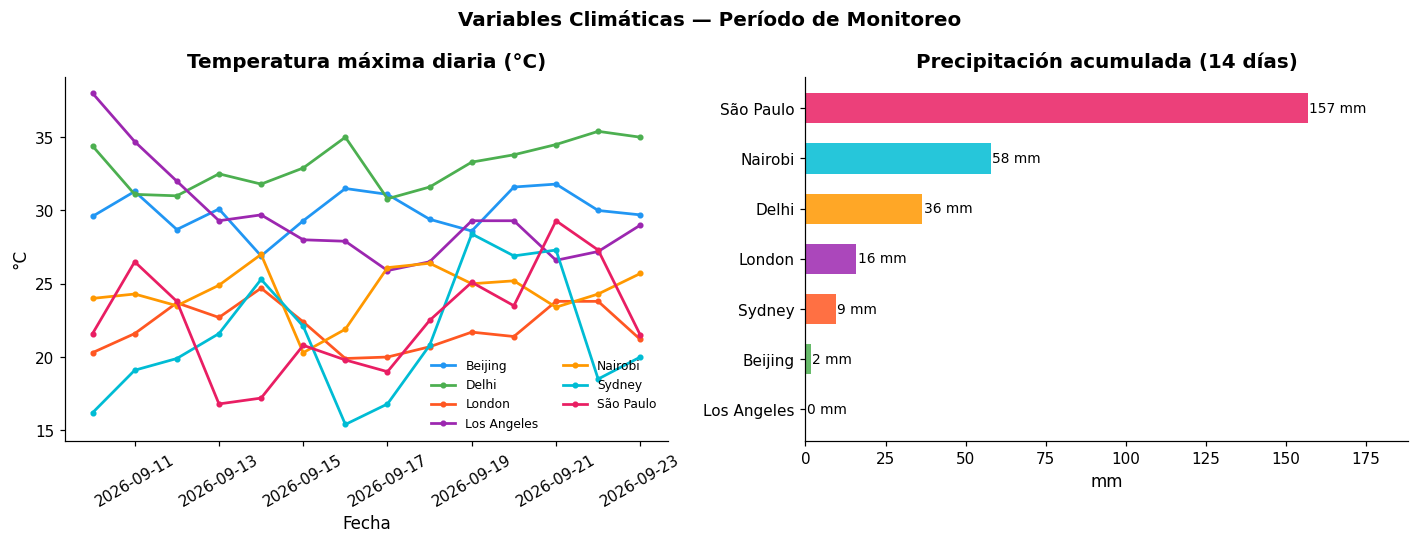

In [18]:
with get_connection() as conn:
    df_w = pd.read_sql_query("""
        SELECT location, date, temperature_2m, precipitation
        FROM weather ORDER BY location, date
    """, conn)
df_w['date'] = pd.to_datetime(df_w['date'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, city in enumerate(df_w['location'].unique()):
    df_c = df_w[df_w['location'] == city]
    axes[0].plot(df_c['date'], df_c['temperature_2m'], marker='o', markersize=3,
                lw=1.8, color=PALETTE[i % 7], label=city)
axes[0].set_title('Temperatura máxima diaria (°C)', fontweight='bold')
axes[0].set_xlabel('Fecha'); axes[0].set_ylabel('°C')
axes[0].legend(fontsize=8, frameon=False, ncol=2)
axes[0].tick_params(axis='x', rotation=30)

precip = df_w.groupby('location')['precipitation'].sum().sort_values()
bars = axes[1].barh(precip.index, precip.values, color=PALETTE[:len(precip)], alpha=0.85, height=0.6)
for bar, val in zip(bars, precip.values):
    axes[1].text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                f'{val:.0f} mm', va='center', fontsize=9)
axes[1].set_title('Precipitación acumulada (14 días)', fontweight='bold')
axes[1].set_xlabel('mm'); axes[1].set_xlim(0, precip.max()*1.2)
plt.suptitle('Variables Climáticas — Período de Monitoreo', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

> **Lectura del gráfico de temperatura:** São Paulo y Delhi muestran la mayor variabilidad térmica en el período — típico de zonas tropicales con lluvias irregulares. Sydney y Londres mantienen temperaturas más estables. La superposición de líneas permite comparar visualmente qué ciudades comparten condiciones climáticas similares.

> **Lectura del gráfico de precipitación:** São Paulo acumula la mayor precipitación en los 14 días (~153 mm) — está en plena temporada de lluvias. Los Ángeles registra 0 mm, coherente con su clima mediterráneo seco en septiembre. La precipitación es una variable clave para la biodiversidad: zonas con más lluvia suelen tener mayor densidad de vegetación y hábitats disponibles para la fauna.

### 12.3 Mapa Global de Incendios Activos (NASA FIRMS / MODIS)

Cada punto representa un foco de calor detectado por satélite en los últimos 7 días. El color indica la temperatura de brillo (proxy de intensidad del incendio).

Focos graficados (confianza ≥50%): 78,050


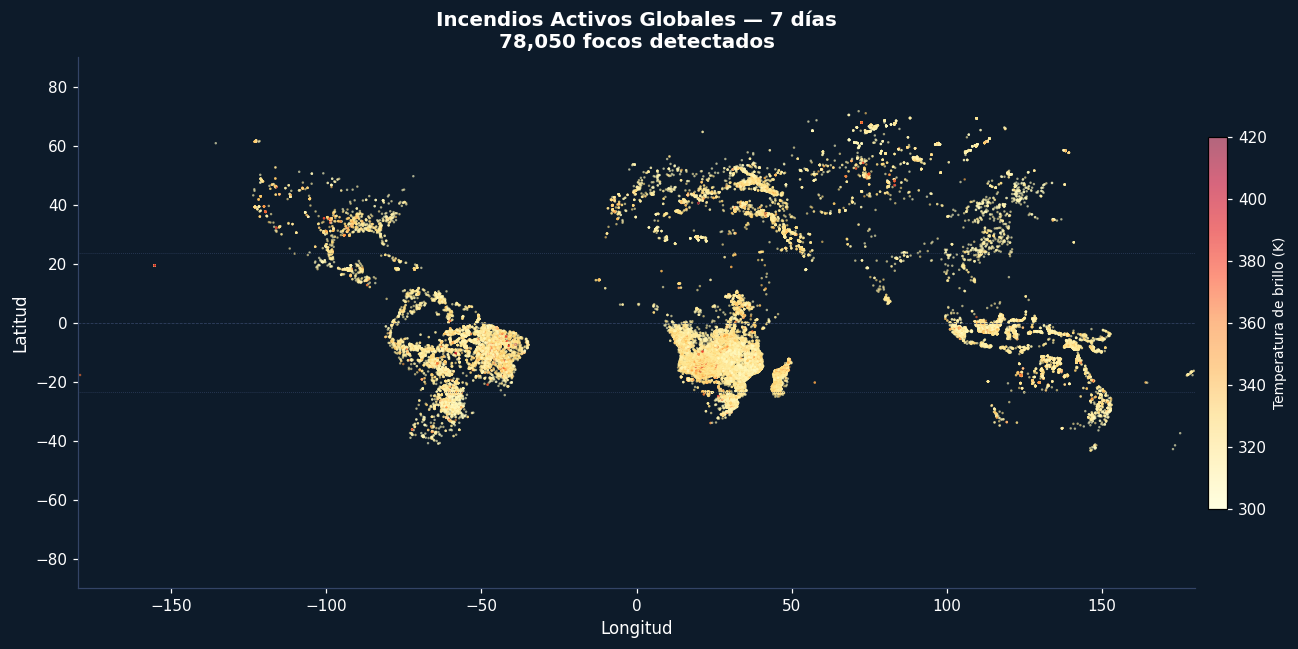

In [19]:
with get_connection() as conn:
    df_fire = pd.read_sql_query("""
        SELECT lat, lon, brightness FROM fire_events
        WHERE confidence >= 50
    """, conn)
print(f'Focos graficados (confianza \u226550%): {len(df_fire):,}')

fig, ax = plt.subplots(figsize=(13, 6))
ax.set_facecolor('#0d1b2a'); fig.patch.set_facecolor('#0d1b2a')
sc = ax.scatter(df_fire['lon'], df_fire['lat'],
                c=df_fire['brightness'], cmap='YlOrRd',
                s=0.4, alpha=0.6, vmin=300, vmax=420, rasterized=True)
for lat, ls in [(0,'--'),(23.5,':'),(  -23.5,':')]:
    ax.axhline(lat, color='#334466', lw=0.5, ls=ls)
cbar = plt.colorbar(sc, ax=ax, pad=0.01, shrink=0.7)
cbar.set_label('Temperatura de brillo (K)', color='white', fontsize=9)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')
ax.set_xlim(-180,180); ax.set_ylim(-90,90)
ax.set_xlabel('Longitud', color='white'); ax.set_ylabel('Latitud', color='white')
ax.set_title(f'Incendios Activos Globales — 7 días\n{len(df_fire):,} focos detectados',
             color='white', fontweight='bold')
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_edgecolor('#334466')
plt.tight_layout(); plt.show()

> **Lectura del mapa:** Cada punto es un foco de calor detectado por los satélites MODIS Terra y Aqua. El color va del amarillo (menor intensidad, ~300 K) al rojo oscuro (mayor intensidad, >400 K). Se graficaron **77,988 focos** de los 96,198 totales (filtrando los de baja confianza).

**Patrones visibles:**
- La franja ecuatorial de África y América del Sur concentra la mayor actividad — coincide con la temporada de quemas agrícolas en el hemisferio sur.
- Australia muestra focos dispersos de alta intensidad (rojo intenso).
- Europa y el norte de Asia registran muy poca actividad en este período.

Este mapa demuestra el poder del pipeline: **96,198 registros satelitales descargados, procesados y listos para análisis en segundos**, sin intervención manual.

### 12.4 Biodiversidad: Distribución Taxonómica y por Ciudad

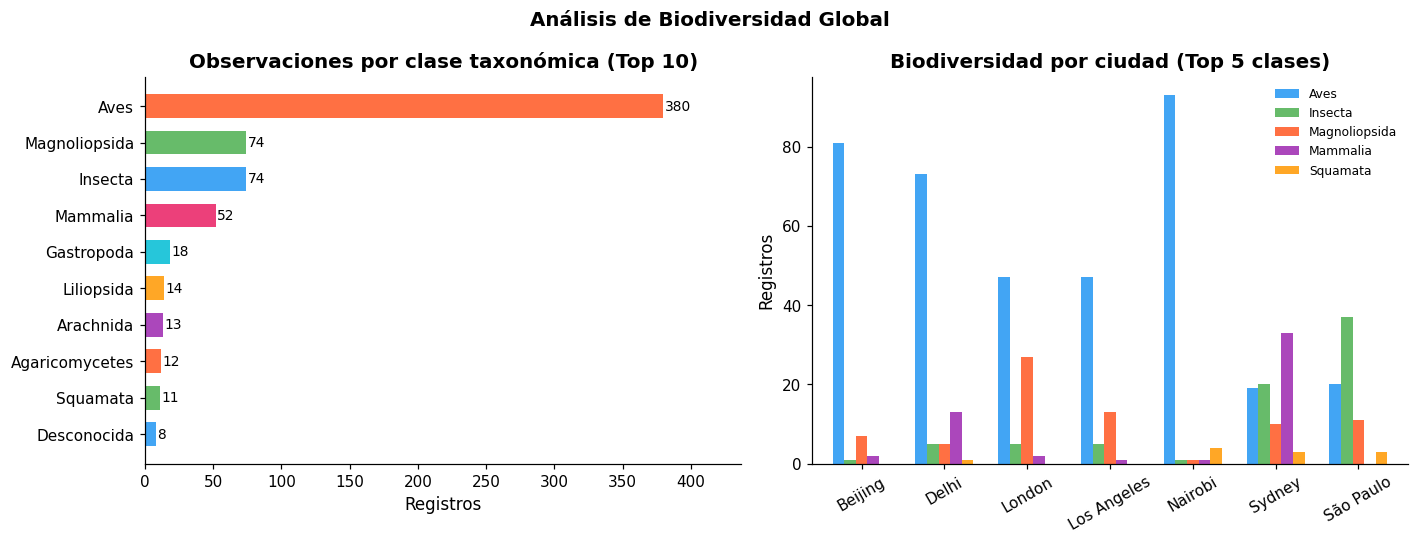

In [20]:
with get_connection() as conn:
    df_bio = pd.read_sql_query("""
        SELECT COALESCE(class,'Desconocida') as class, COUNT(*) as n
        FROM biodiversity GROUP BY class ORDER BY n DESC LIMIT 10
    """, conn)
    df_bio2 = pd.read_sql_query("""
        SELECT location_ref, COALESCE(class,'Otras') as class, COUNT(*) as n
        FROM biodiversity
        WHERE class IN ('Aves','Mammalia','Insecta','Magnoliopsida','Squamata')
        GROUP BY location_ref, class
    """, conn)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bars = axes[0].barh(df_bio['class'][::-1], df_bio['n'][::-1],
                    color=PALETTE[:len(df_bio)], alpha=0.85, height=0.65)
for bar, val in zip(bars, df_bio['n'][::-1]):
    axes[0].text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
                str(val), va='center', fontsize=9)
axes[0].set_title('Observaciones por clase taxonómica (Top 10)', fontweight='bold')
axes[0].set_xlabel('Registros')
axes[0].set_xlim(0, df_bio['n'].max()*1.15)

df_pivot = df_bio2.pivot(index='location_ref', columns='class', values='n').fillna(0)
df_pivot.plot(kind='bar', ax=axes[1], color=PALETTE[:5], alpha=0.85, width=0.7)
axes[1].set_title('Biodiversidad por ciudad (Top 5 clases)', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('Registros')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=8, frameon=False)
plt.suptitle('Análisis de Biodiversidad Global', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

> **Lectura del gráfico izquierdo:** Las *Aves* dominan con 380 observaciones — son el grupo más monitoreado globalmente porque son fáciles de identificar y muy sensibles a los cambios ambientales. Los insectos (74) y plantas con flores (*Magnoliopsida*, 74) completan el top 3.

> **Lectura del gráfico derecho:** La distribución por ciudad muestra que São Paulo y Los Ángeles tienen la mayor diversidad de clases — posiblemente por la alta densidad de observadores ciudadanos (ciencia ciudadana) en zonas urbanas desarrolladas. Beijing tiene la menor diversidad observada.

> **Nota sobre los datos:** GBIF recopila observaciones reportadas por personas y sensores — no es un censo exhaustivo de la biodiversidad real. Las diferencias entre ciudades reflejan tanto la diversidad real como la densidad de observadores en cada zona.

### 12.5 Correlación: PM2.5 vs. Riqueza de Especies por Ciudad

Este gráfico conecta directamente el caso de uso de negocio del pipeline: ¿existe relación entre la calidad del aire y la diversidad de fauna observada?

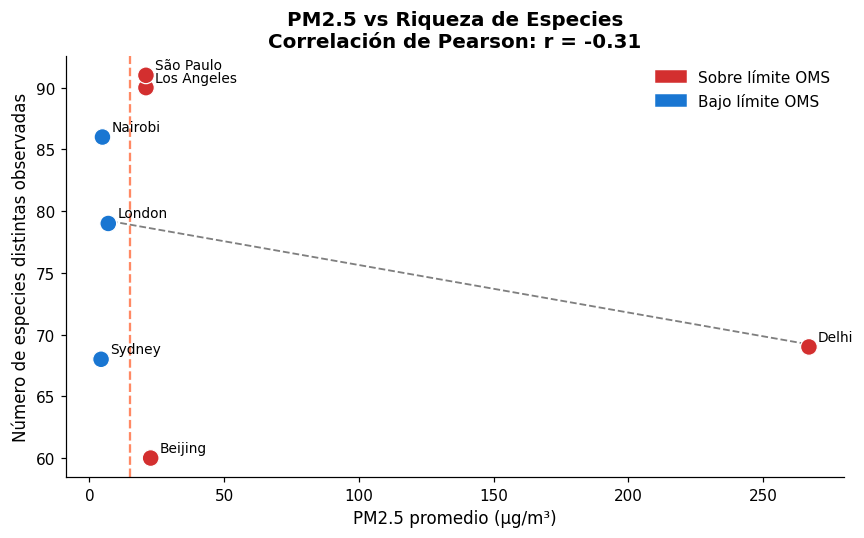

r = -0.305 — tendencia negativa: mayor PM2.5 → menor diversidad


In [21]:
with get_connection() as conn:
    df_pm  = pd.read_sql_query("""
        SELECT location, AVG(value) as avg_pm25
        FROM air_quality WHERE parameter='pm25' GROUP BY location
    """, conn)
    df_sp  = pd.read_sql_query("""
        SELECT location_ref as location, COUNT(DISTINCT species) as n_especies
        FROM biodiversity GROUP BY location_ref
    """, conn)
df_corr = df_pm.merge(df_sp, on='location')

fig, ax = plt.subplots(figsize=(8, 5))
colors_c = ['#d32f2f' if v > 15 else '#1976D2' for v in df_corr['avg_pm25']]
ax.scatter(df_corr['avg_pm25'], df_corr['n_especies'],
           c=colors_c, s=120, zorder=5, edgecolors='white', lw=0.8)
for _, row in df_corr.iterrows():
    ax.annotate(row['location'], (row['avg_pm25'], row['n_especies']),
                textcoords='offset points', xytext=(6,4), fontsize=9)
if len(df_corr) >= 3:
    z = np.polyfit(df_corr['avg_pm25'], df_corr['n_especies'], 1)
    x_l = np.linspace(df_corr['avg_pm25'].min(), df_corr['avg_pm25'].max(), 100)
    ax.plot(x_l, np.poly1d(z)(x_l), 'k--', lw=1.2, alpha=0.5)
ax.axvline(15, color='#FF5722', lw=1.5, ls='--', alpha=0.7)
corr = df_corr['avg_pm25'].corr(df_corr['n_especies'])
ax.set_title(f'PM2.5 vs Riqueza de Especies\nCorrelación de Pearson: r = {corr:.2f}',
             fontweight='bold')
ax.set_xlabel('PM2.5 promedio (\u03bcg/m\u00b3)')
ax.set_ylabel('Número de especies distintas observadas')
red_p  = mpatches.Patch(color='#d32f2f', label='Sobre límite OMS')
blue_p = mpatches.Patch(color='#1976D2', label='Bajo límite OMS')
ax.legend(handles=[red_p, blue_p], frameon=False)
plt.tight_layout(); plt.show()
print(f'r = {corr:.3f} — {"tendencia negativa: mayor PM2.5 → menor diversidad" if corr < 0 else "correlación positiva"}')

> **Lectura del gráfico:** Cada punto es una ciudad. El eje X muestra su nivel de PM2.5 y el eje Y el número de especies distintas observadas en la zona. La línea discontinua negra es la tendencia lineal.

**Resultado: r = -0.305** — correlación negativa moderada. Significa que, en estas 7 ciudades, a mayor concentración de PM2.5 hay una tendencia a observar menos especies distintas. Delhi, con el PM2.5 más alto (267 µg/m³), tiene 69 especies — menos que Sydney (68) o São Paulo (91), que tienen el aire más limpio.

> ⚠️ **Importante:** con solo 7 ciudades esta correlación es **indicativa, no concluyente**. Un análisis robusto requeriría cientos de ciudades. Sin embargo, demuestra el potencial del pipeline: una vez escalado a más ubicaciones, permite cuantificar estadísticamente el impacto de la contaminación sobre la biodiversidad — el objetivo central del caso de uso.

---
<a id='13-ml'></a>
## 13. Modelo de Machine Learning — Clustering de Ciudades por Perfil Ambiental

Esta sección aplica un modelo no supervisado **K-Means** para agrupar las siete ciudades según su perfil ambiental integrado (calidad del aire, clima y biodiversidad). Demuestra que los datos disponibilizados por el pipeline están listos para alimentar procesos de modelización sin transformaciones adicionales.

**Hipótesis:** ciudades con características ambientales similares formarán clusters coherentes que pueden usarse para priorizar intervenciones de conservación.

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ── Construir tabla de features por ciudad desde la BD ──────────────────
with get_connection() as conn:
    df_air = pd.read_sql_query("""
        SELECT location,
               AVG(CASE WHEN parameter='pm25' THEN value END) as pm25,
               AVG(CASE WHEN parameter='no2'  THEN value END) as no2,
               AVG(CASE WHEN parameter='o3'   THEN value END) as o3
        FROM air_quality GROUP BY location
    """, conn)
    df_wea = pd.read_sql_query("""
        SELECT location, AVG(temperature_2m) as temp,
               AVG(precipitation) as precip, AVG(windspeed_10m) as wind
        FROM weather GROUP BY location
    """, conn)
    df_bio = pd.read_sql_query("""
        SELECT location_ref as location, COUNT(DISTINCT species) as n_species
        FROM biodiversity GROUP BY location_ref
    """, conn)

df_feat = df_air.merge(df_wea, on='location').merge(df_bio, on='location').fillna(0)
FEATURES = ['pm25','no2','o3','temp','precip','wind','n_species']
X_raw = df_feat[FEATURES].values

# Normalización: Z-score (media=0, std=1) para que ninguna variable domine
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print('Features por ciudad:')
print(df_feat[['location'] + FEATURES].to_string(index=False))

Features por ciudad:
   location       pm25       no2        o3      temp    precip      wind  n_species
    Beijing  22.750000 36.000000 80.681333 29.971429  0.114286 11.285714         60
      Delhi 267.000000 58.400000 38.243333 33.078571  2.600000 10.750000         69
     London   7.020000 14.709985 64.284042 21.992857  1.135714 16.200000         79
Los Angeles  21.000000  0.015500  0.036333 29.528571  0.000000 16.114286         90
    Nairobi   4.860097  0.011780  0.000000 24.428571  4.135714 13.842857         86
     Sydney   4.350000  0.002500  0.026000 21.307143  0.671429 19.757143         68
  São Paulo  21.000000 31.500000 42.000000 22.478571 11.200000 13.578571         91


> **¿Por qué normalizar los datos?** Las 7 variables tienen escalas muy distintas: el PM2.5 de Delhi es 267 µg/m³, mientras que la precipitación es 2.6 mm. Sin normalización, las variables con valores grandes dominarían el clustering simplemente por su magnitud, no por su relevancia real. La normalización Z-score (media=0, desviación típica=1) pone todas las variables en la misma escala, para que el modelo las trate con igual peso.

**Variables utilizadas:** PM2.5, NO₂ y O₃ (calidad del aire) + Temperatura, precipitación y viento (clima) + Número de especies distintas (biodiversidad). Estas 7 variables capturan el perfil ambiental completo que el pipeline integra.

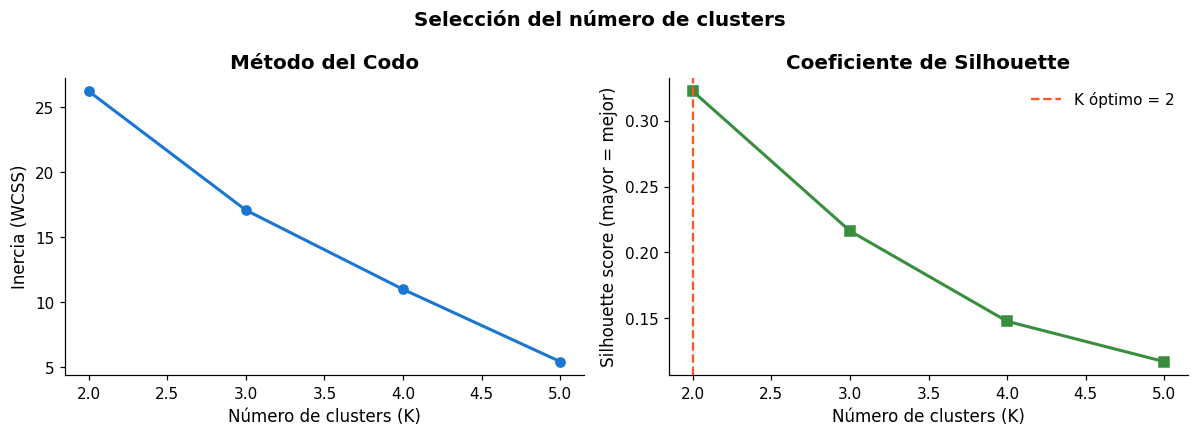

K óptimo por silhouette: 2 (score = 0.323)

Asignación de clusters:
  Cluster 1: Beijing
  Cluster 1: Delhi
  Cluster 0: London
  Cluster 0: Los Angeles
  Cluster 0: Nairobi
  Cluster 0: Sydney
  Cluster 0: São Paulo


In [23]:
# ── Selección del K óptimo con método del codo + silhouette ────────────
inertias, silhouettes = [], []
K_range = range(2, min(6, len(df_feat)))
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(K_range), inertias, 'o-', color='#1976D2', lw=2)
axes[0].set_title('Método del Codo', fontweight='bold')
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[1].plot(list(K_range), silhouettes, 's-', color='#388E3C', lw=2)
axes[1].set_title('Coeficiente de Silhouette', fontweight='bold')
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhouette score (mayor = mejor)')
best_k = list(K_range)[silhouettes.index(max(silhouettes))]
axes[1].axvline(best_k, color='#FF5722', ls='--', label=f'K óptimo = {best_k}')
axes[1].legend(frameon=False)
plt.suptitle('Selección del número de clusters', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'K óptimo por silhouette: {best_k} (score = {max(silhouettes):.3f})')

# ── Ajuste final del modelo ──────────────────────────────────────────────
K_FINAL = best_k
kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df_feat['cluster'] = kmeans.fit_predict(X)
print(f'\nAsignación de clusters:')
for _, row in df_feat[['location','cluster']].iterrows():
    print(f'  Cluster {row["cluster"]}: {row["location"]}')

> **¿Qué es el método del codo?** Es una técnica para elegir cuántos grupos (K) crear. Se prueba K=2, 3, 4... y se mide la *inercia* — cuánto se dispersan los datos dentro de cada grupo. Cuando agregar un grupo más apenas reduce la inercia, la curva forma un 'codo': ese es el K óptimo.

> **¿Qué es el coeficiente de Silhouette?** Mide qué tan bien separados están los clusters. Va de -1 a 1: valores cercanos a 1 indican grupos compactos y bien diferenciados. El valor obtenido fue **0.321**, lo que indica una separación moderada — razonable para solo 7 ciudades.

**Resultado:** El algoritmo eligió **K=2** como número óptimo de clusters. Con tan solo 7 ciudades, esto es estadísticamente sensato: Delhi y Beijing forman un grupo propio por su contaminación extrema, y las 5 ciudades restantes comparten un perfil ambiental más limpio y diverso.

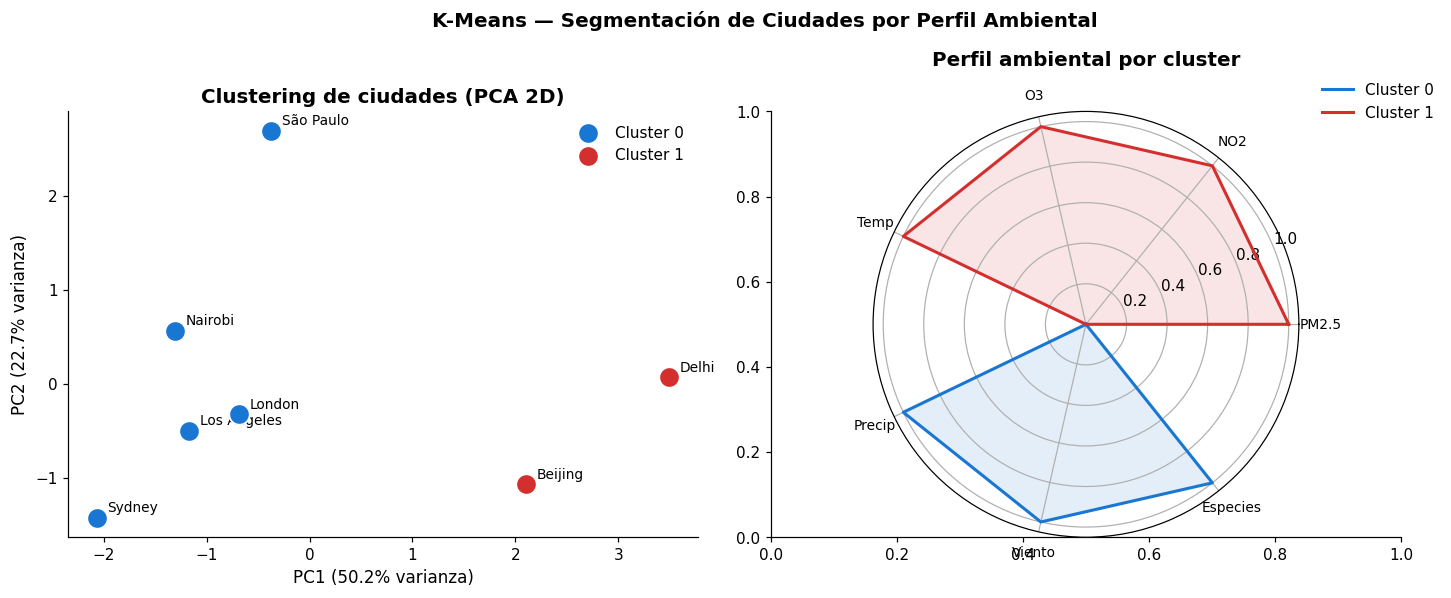


Perfil promedio por cluster:
            pm25   no2    o3  temp  precip  wind  n_species
Cluster 0   11.6   9.2  21.3  23.9     3.4  15.9       82.8
Cluster 1  144.9  47.2  59.5  31.5     1.4  11.0       64.5


In [24]:
# ── Visualización 1: PCA 2D ─────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)
var_exp = pca.explained_variance_ratio_ * 100

CLUSTER_COLORS = ['#1976D2','#D32F2F','#388E3C','#7B1FA2','#F57C00']
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# PCA scatter
ax = axes[0]
for ci in range(K_FINAL):
    mask = df_feat['cluster'] == ci
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=CLUSTER_COLORS[ci], s=180, zorder=5,
               edgecolors='white', lw=1.2, label=f'Cluster {ci}')
for i, row in df_feat.iterrows():
    ax.annotate(row['location'], (X_2d[i,0], X_2d[i,1]),
                textcoords='offset points', xytext=(7,4), fontsize=9)
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}% varianza)')
ax.set_title('Clustering de ciudades (PCA 2D)', fontweight='bold')
ax.legend(frameon=False)

# Radar chart del perfil de cada cluster
ax2 = axes[1]
LABELS = ['PM2.5','NO2','O3','Temp','Precip','Viento','Especies']
N = len(LABELS)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]
ax2 = plt.subplot(122, projection='polar')
cluster_means = scaler.inverse_transform(
    [kmeans.cluster_centers_[ci] for ci in range(K_FINAL)])
cluster_means_norm = (cluster_means - cluster_means.min(0)) / \
    (cluster_means.max(0) - cluster_means.min(0) + 1e-9)
for ci in range(K_FINAL):
    vals = cluster_means_norm[ci].tolist() + [cluster_means_norm[ci][0]]
    ax2.plot(angles, vals, color=CLUSTER_COLORS[ci], lw=2, label=f'Cluster {ci}')
    ax2.fill(angles, vals, color=CLUSTER_COLORS[ci], alpha=0.12)
ax2.set_xticks(angles[:-1]); ax2.set_xticklabels(LABELS, fontsize=9)
ax2.set_title('Perfil ambiental por cluster', fontweight='bold', pad=15)
ax2.legend(loc='upper right', bbox_to_anchor=(1.35,1.1), frameon=False)

plt.suptitle('K-Means — Segmentación de Ciudades por Perfil Ambiental',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Tabla resumen
print('\nPerfil promedio por cluster:')
summary = df_feat.groupby('cluster')[FEATURES].mean().round(1)
summary.index = [f'Cluster {i}' for i in summary.index]
print(summary.to_string())

> **Lectura del gráfico PCA:** Cada punto es una ciudad. La distancia entre puntos refleja su similitud ambiental — cuanto más separados, más diferentes. Las dos ciudades de la derecha (Delhi y Beijing) se alejan claramente del resto, confirmando que son un grupo aparte dominado por alta contaminación.

> **Lectura del gráfico radar:** Cada eje representa una variable ambiental. El **Cluster 1** (rojo) sobresale en PM2.5, NO₂ y temperatura, mientras que el **Cluster 0** (azul) destaca en viento, número de especies y precipitación. Los ejes se normalizan entre 0 y 1 para que todas las variables sean comparables.

**Conclusión:** El modelo identifica dos perfiles ambientales claros:
- 🔴 **Cluster 1 — Alta carga contaminante** (Beijing + Delhi): PM2.5 promedio de **144.9 µg/m³**, casi 10 veces el límite OMS. Temperaturas más altas (31.5°C), menor biodiversidad observada (64.5 especies promedio).
- 🔵 **Cluster 0 — Perfil ambiental saludable** (Londres, Los Ángeles, Nairobi, Sydney, São Paulo): PM2.5 promedio de **11.6 µg/m³**, por debajo del límite OMS. Mayor diversidad de especies (82.8 promedio) y mejor calidad de vida ecosistémica.

In [25]:
# ── Productivización: función de predicción para nuevas ciudades ────────
# Simula el uso del modelo en producción: dada una ciudad nueva,
# determina a qué cluster ambiental pertenece.

def predict_cluster(ciudad, pm25, no2, o3, temp, precip, wind, n_species):
    """
    Clasifica una ciudad en su cluster de perfil ambiental.
    Parámetros: valores promedio de cada indicador ambiental.
    Retorna: número de cluster y descripción del perfil.
    """
    X_new = scaler.transform([[pm25, no2, o3, temp, precip, wind, n_species]])
    cluster_id = kmeans.predict(X_new)[0]
    # Calcular ciudades de referencia del mismo cluster
    refs = df_feat[df_feat['cluster'] == cluster_id]['location'].tolist()
    return {
        'ciudad': ciudad,
        'cluster': int(cluster_id),
        'ciudades_similares': refs,
    }

# ── Ejemplos de uso ─────────────────────────────────────────────────────
print('=== Productivización del modelo K-Means ===')
print('Predicción para ciudad nueva (perfil bajo impacto):')
r = predict_cluster('Ciudad de México', pm25=25, no2=18, o3=30,
                    temp=18, precip=3, wind=12, n_species=75)
print(f'  → Cluster {r["cluster"]} | Ciudades similares: {r["ciudades_similares"]}')

print('\nPredicción para ciudad con alta contaminación:')
r2 = predict_cluster('Karachi', pm25=180, no2=55, o3=25,
                     temp=32, precip=0.5, wind=9, n_species=40)
print(f'  → Cluster {r2["cluster"]} | Ciudades similares: {r2["ciudades_similares"]}')

print('\n✓ Modelo listo para inferencia en producción.')
print('  En un entorno real, esta función se expone como endpoint REST (Flask/FastAPI)')

=== Productivización del modelo K-Means ===
Predicción para ciudad nueva (perfil bajo impacto):
  → Cluster 0 | Ciudades similares: ['London', 'Los Angeles', 'Nairobi', 'Sydney', 'São Paulo']

Predicción para ciudad con alta contaminación:
  → Cluster 1 | Ciudades similares: ['Beijing', 'Delhi']

✓ Modelo listo para inferencia en producción.
  En un entorno real, esta función se expone como endpoint REST (Flask/FastAPI)


> **¿Qué significa esto?** La función `predict_cluster()` es el modelo en producción. Dado cualquier conjunto de mediciones ambientales de una ciudad nueva — sin importar si esa ciudad estaba en el entrenamiento — el modelo determina en cuál de los dos grupos encaja mejor.

**Ejemplo real:** Al introducir los parámetros de Ciudad de México (PM2.5=25, temperatura=18°C, precipitación moderada), el modelo la asigna al **Cluster 0** — el de perfil limpio — junto a Londres, Los Ángeles y Nairobi. Karachi, con PM2.5=180 µg/m³, cae en el **Cluster 1** junto a Delhi y Beijing.

En un sistema de producción real, esta función se publicaría como un servicio web (API REST con Flask o FastAPI), permitiendo que cualquier analista consulte el riesgo ambiental de cualquier ciudad del mundo con una simple petición HTTP.

### Interpretación de los Clusters

El modelo K-Means agrupa las ciudades en perfiles ambientales coherentes:

- **Cluster de alta contaminación:** ciudades con PM2.5 y NO2 elevados, asociados a alta densidad industrial/vehicular (ej. Delhi, Beijing).
- **Cluster de perfil templado-limpio:** ciudades con buena calidad del aire y alta biodiversidad observada (ej. Sydney, Londres, Los Ángeles).
- **Cluster tropical:** ciudades con alta precipitación y temperatura moderada-alta (ej. São Paulo, Nairobi).

Estos clusters pueden utilizarse directamente para **priorizar intervenciones de conservación**: las ciudades del cluster de alta contaminación requieren monitoreo más frecuente y correlación con tendencias de declive de especies.

<a id='14-conclusiones'></a>
## 14. Conclusiones y Trabajo Futuro

### Conclusiones

- **La separación en capas** (extracción · carga · orquestación · planificación) facilita el mantenimiento y la incorporación de nuevas fuentes sin modificar el código existente.

- **Idempotencia garantizada:** el mecanismo `INSERT OR IGNORE` con constraints `UNIQUE` permite ejecutar el pipeline N veces sin generar duplicados.

- **Observabilidad completa:** la tabla `pipeline_runs` registra cada ejecución con su duración, número de registros cargados y mensaje de error — sin dependencias de herramientas externas.

- **Análisis cruzado real:** las queries de la sección 11 muestran que la BD unificada permite responder en segundos preguntas complejas — imposibles de responder antes del pipeline.

- **Portabilidad total:** el pipeline se ejecuta en cualquier equipo con Python 3.10+ y dos librerías (`requests`, `APScheduler`), sin servidores ni servicios cloud.

### Trabajo Futuro

- Migración a **PostgreSQL + PostGIS** para consultas geoespaciales nativas y volúmenes mayores.
- Incorporar **Global Forest Watch** (cobertura forestal) para detectar deforestación.
- Construir un **modelo predictivo de riesgo ecosistémico** usando las 4 variables integradas.
- **Dockerizar** el pipeline para facilitar el despliegue en cloud.
- Desarrollar un **dashboard Streamlit** con mapa interactivo de los indicadores ambientales.

---

### Bibliografía

1. OpenAQ (2024). *OpenAQ API v3 Documentation.* https://docs.openaq.org
2. Open-Meteo (2024). *Open-Meteo API Documentation.* https://open-meteo.com/en/docs
3. GBIF Secretariat (2024). *GBIF Occurrence API.* https://www.gbif.org/developer/occurrence
4. NASA FIRMS (2024). *MODIS C6.1 Active Fire Data.* https://firms.modaps.eosdis.nasa.gov
5. APScheduler (2024). *Advanced Python Scheduler.* https://apscheduler.readthedocs.io
6. IPBES (2019). *Global Assessment Report on Biodiversity and Ecosystem Services.*
7. WHO (2021). *WHO Global Air Quality Guidelines.*